In [1]:
project_dir = "/Users/danieljanini/Documents/project_miniblock"
import os

In [97]:
from os.path import join
import os
import numpy as np
import nibabel as nib
from nilearn import image, plotting
import glob
import pandas as pd
from scipy.stats import ttest_1samp, false_discovery_control, ttest_rel
from statsmodels.stats.multitest import fdrcorrection

outdir = join(project_dir, 'miniblock/Outputs')
datadir = join(project_dir, 'miniblock')
presdir = join(project_dir, "Behavior/designmats")
smooths = ['sm_2_vox']
categories = ["Faces", "Objects", "Scenes", "Bodies"]
ROIs = ["FFA", "EBA", "PPA"]
subjects = [f"{i:02d}" for i in range(1,23) if i not in [9,16]]

shape = image.load_img(join(datadir, 'derivatives', 'sub-01', 'anat', 'sub-01_space-MNI152NLin2009cAsym_desc-brain_mask_resampled.nii.gz')).get_fdata().shape
sum_face_v_obj = np.zeros(shape = shape)
sum_scene_v_obj = np.zeros(shape = shape)
sum_body_v_obj = np.zeros(shape = shape)

for sub in subjects: 
    for smoothing in smooths: 
        for ROI in ROIs:
            results_glmsingle = dict()
            results_glmsingle['typed'] = np.load(join(outdir,'GLMSingle_Outputs','localizer',f'{smoothing}_sub-{sub}_TYPED_FITHRF_GLMDENOISE_RR.npy'), allow_pickle=True).item()
            betas = results_glmsingle['typed']['betasmd']

            whole_brain_mask_initial = image.load_img(join(datadir, 'derivatives', f'sub-{sub}', 'anat', f'sub-{sub}_space-MNI152NLin2009cAsym_desc-brain_mask_resampled.nii.gz'))
            whole_brain_mask = whole_brain_mask_initial.get_fdata()         

            masked_betas = betas[whole_brain_mask.astype(bool)]
            unmasked_betas = np.zeros(betas.shape)
            unmasked_betas[whole_brain_mask.astype(bool)] = masked_betas

            pattern = presdir + f'/localizer/P0{sub}_CategoryLocalizer_Run*.csv'
            matches = glob.glob(pattern)
            matches.sort()
            
            design = []
            for i in range(len(matches)):
                designMat = pd.read_csv(matches[i], header=None)
                design.append(designMat)

            full_design = np.vstack(design)
            faces_idx = np.where(full_design[:, categories.index("Faces")] == 1)[0]
            objects_idx = np.where(full_design[:, categories.index("Objects")] == 1)[0]
            scenes_idx = np.where(full_design[:, categories.index("Scenes")] == 1)[0]
            bodies_idx = np.where(full_design[:, categories.index("Bodies")] == 1)[0]


            event_list = []
            event_list += [(time, 'Faces') for time in faces_idx]
            event_list += [(time, 'Objects') for time in objects_idx]
            event_list += [(time, 'Scenes') for time in scenes_idx]
            event_list += [(time, 'Bodies') for time in bodies_idx]

            # Sort them by time
            event_list.sort(key=lambda x: x[0])

            # Now get the condition labels in presentation order
            conditions_in_order = [condition for (_, condition) in event_list]

            conditions_in_order = np.array(conditions_in_order)

            trial_indices = {
                'Faces': np.where(conditions_in_order == 'Faces')[0],
                'Objects': np.where(conditions_in_order == 'Objects')[0],
                'Scenes': np.where(conditions_in_order == 'Scenes')[0],
                'Bodies': np.where(conditions_in_order == 'Bodies')[0],
            }

            # Define contrast depending on ROI
            contrast_def = {
                "FFA": ("Faces", "Objects"),
                "PPA": ("Scenes", "Objects"),
                "EBA": ("Bodies", "Objects")
            }

            cond1, cond2 = contrast_def[ROI]
            cond1_betas = unmasked_betas[..., trial_indices[cond1]]
            cond2_betas = unmasked_betas[..., trial_indices[cond2]]

            # Paired t-test
            tvals, pvals = ttest_rel(cond1_betas, cond2_betas, axis=-1, alternative="greater")
            # pvals_flat = pvals.flatten()

            # not_nan_mask = ~np.isnan(pvals_flat)

            # # Run FDR only on valid values
            # _, pvals_corrected_flat = fdrcorrection(pvals_flat[not_nan_mask])

            # # Prepare an array filled with nan, then fill the valid entries
            # pvals_corrected_full = np.full_like(pvals_flat, np.nan)
            # pvals_corrected_full[not_nan_mask] = pvals_corrected_flat
            # # Reshape back
            # pvals_corrected = pvals_corrected_full.reshape(pvals.shape)
            # significant_mask = pvals_corrected < 0.01
            significant_mask = pvals < 0.001
            tvals_thresholded = tvals * significant_mask
            binary_mask = (tvals_thresholded > 0).astype(np.uint8)
            if ROI == "FFA":
                sum_face_v_obj += binary_mask
            elif ROI == "EBA":
                sum_body_v_obj += binary_mask
            elif ROI == "PPA":
                sum_scene_v_obj += binary_mask

In [98]:
face_img = nib.Nifti1Image(sum_face_v_obj, affine=whole_brain_mask_initial.affine)
scene_img = nib.Nifti1Image(sum_scene_v_obj, affine=whole_brain_mask_initial.affine)
body_img = nib.Nifti1Image(sum_body_v_obj, affine=whole_brain_mask_initial.affine)

nib.save(face_img, join(outdir, 'masking', "sum_face_v_objects.nii"))
nib.save(scene_img, join(outdir, 'masking', "sum_scene_v_objects.nii"))
nib.save(body_img, join(outdir, 'masking', "sum_body_v_objects.nii"))

In [8]:
sum_body_v_obj_filtered = sum_body_v_obj > 7
sum_body_v_obj_filtered=sum_body_v_obj_filtered.astype(np.uint8)
body_img_filtered = nib.Nifti1Image(sum_body_v_obj_filtered,affine=whole_brain_mask_initial.affine)
nib.save(body_img_filtered, join(outdir, 'masking', "sum_body_v_objects_filtered.nii"))

/opt/anaconda3/envs/my_python_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/Users/danieljanini/.local/lib/python3.12/site-packages/nilearn/plotting/html_document.py:102: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  warnings.warn(



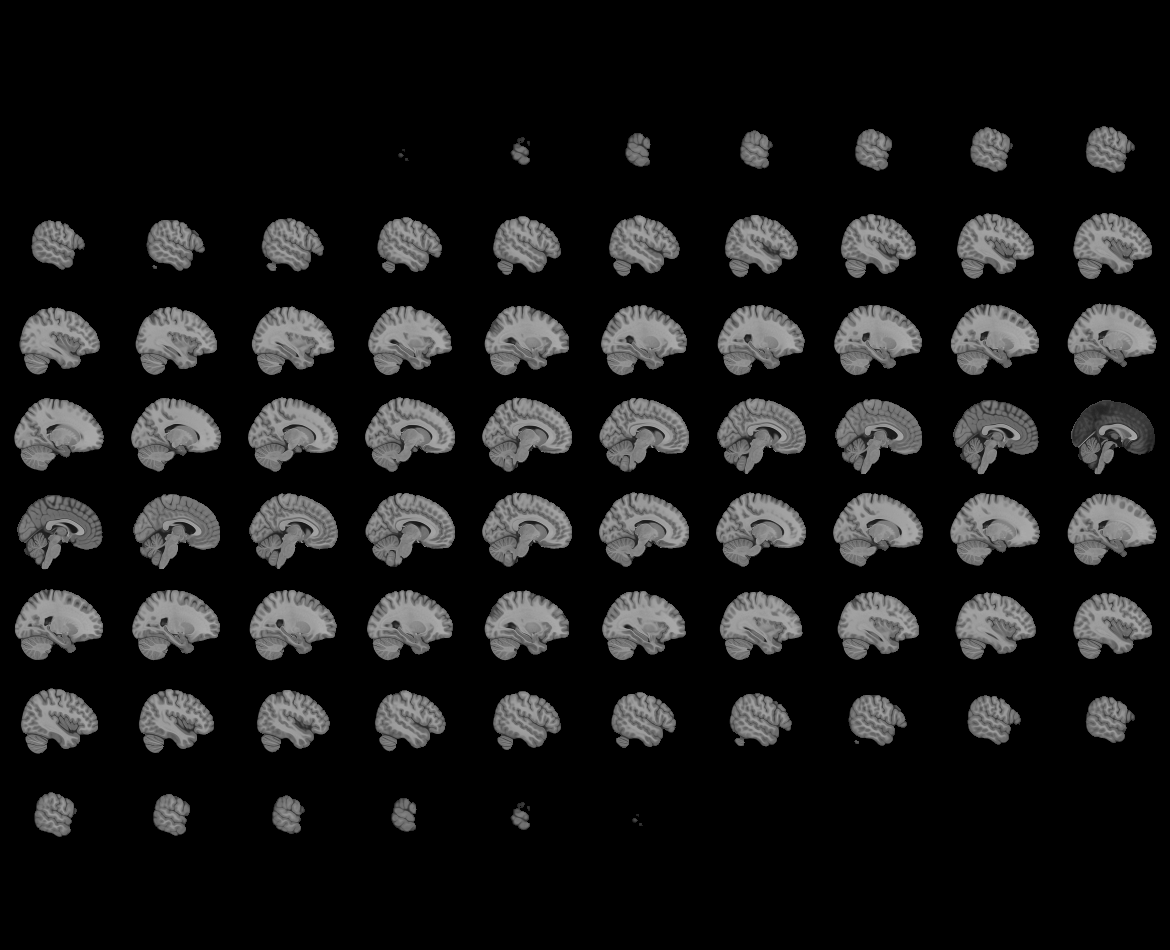
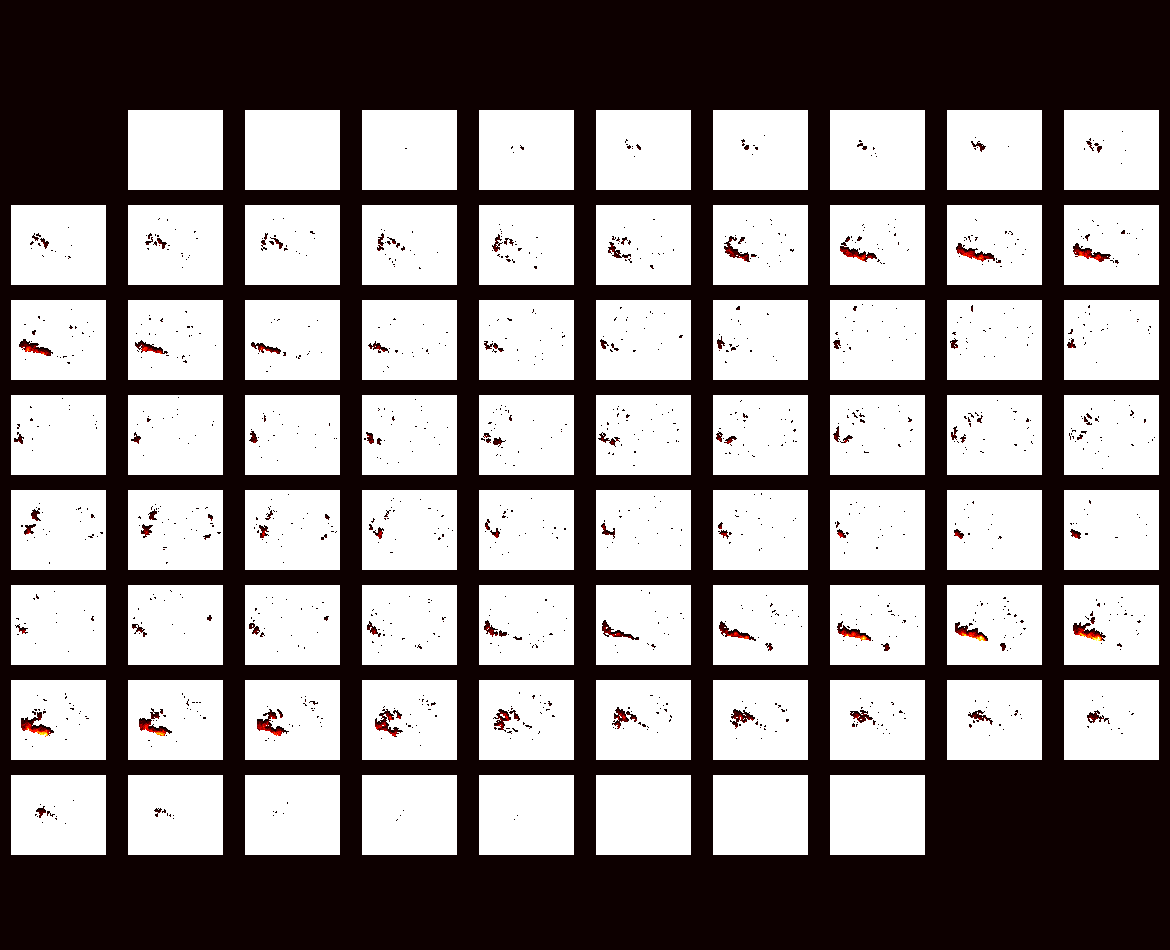

In [61]:
plotting.view_img(face_img)

In [99]:
import numpy as np
import nibabel as nib
from scipy.ndimage import label
from collections import Counter
from scipy.ndimage import gaussian_filter

def extract_clusters(
    input_nii_path,
    output_nii_path,
    part_thresh=2,
    min_cluster_size=50
):
    """
    Extracts clusters from a thresholded NIfTI volume and saves them labeled by size.
    
    Parameters:
        input_nii_path (str): Path to input NIfTI file.
        output_nii_path (str): Path to save the output cluster-labeled NIfTI file.
        part_thresh (float): Threshold below which voxels are excluded.
        min_cluster_size (int): Minimum voxel count for a cluster to be retained.
    """
    # Load NIfTI file
    nii = nib.load(input_nii_path)
    vol = nii.get_fdata()

    # Threshold the data
    vol[vol < part_thresh] = 0

    # Get binary mask and label clusters
    labeled_array, _ = label(vol > 0)

    # Count voxels per label
    label_counts = Counter(labeled_array.flatten())
    label_counts.pop(0, None)  # Remove background

    # Filter small clusters
    filtered_labels = {
        lbl: cnt for lbl, cnt in label_counts.items() if cnt >= min_cluster_size
    }

    # Sort labels by cluster size (descending)
    sorted_labels = sorted(filtered_labels.items(), key=lambda x: -x[1])
    label_mapping = {old_lbl: new_lbl + 1 for new_lbl, (old_lbl, _) in enumerate(sorted_labels)}

    # Create relabeled output
    relabel_map = np.zeros_like(labeled_array, dtype=np.int16)
    for old_lbl, new_lbl in label_mapping.items():
        relabel_map[labeled_array == old_lbl] = new_lbl

    print(f"Retained {len(label_mapping)} clusters ≥ {min_cluster_size} voxels")

    # Save to output NIfTI
    labeled_nii = nib.Nifti1Image(relabel_map, affine=nii.affine, header=nii.header)
    nib.save(labeled_nii, output_nii_path)
    print(f"Saved labeled clusters to: {output_nii_path}")

extract_clusters(
    join(outdir, 'masking', "sum_face_v_objects.nii"),
    join(outdir,'masking','sum_face_clusters.nii'),
    part_thresh=2,
    min_cluster_size=50)

extract_clusters(
    join(outdir, 'masking', "sum_scene_v_objects.nii"),
    join(outdir,'masking','sum_scene_clusters.nii'),
    part_thresh=2,
    min_cluster_size=50)

extract_clusters(
    join(outdir, 'masking', "sum_body_v_objects.nii"),
    join(outdir,'masking','sum_body_clusters.nii'),
    part_thresh=2,
    min_cluster_size=50)

Retained 6 clusters ≥ 50 voxels
Saved labeled clusters to: /Users/danieljanini/Documents/project_miniblock/miniblock/Outputs/masking/sum_face_clusters.nii
Retained 3 clusters ≥ 50 voxels
Saved labeled clusters to: /Users/danieljanini/Documents/project_miniblock/miniblock/Outputs/masking/sum_scene_clusters.nii
Retained 12 clusters ≥ 50 voxels
Saved labeled clusters to: /Users/danieljanini/Documents/project_miniblock/miniblock/Outputs/masking/sum_body_clusters.nii


In [100]:
np.unique(image.load_img(join(outdir,'masking','sum_body_clusters.nii')).get_fdata())

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.])


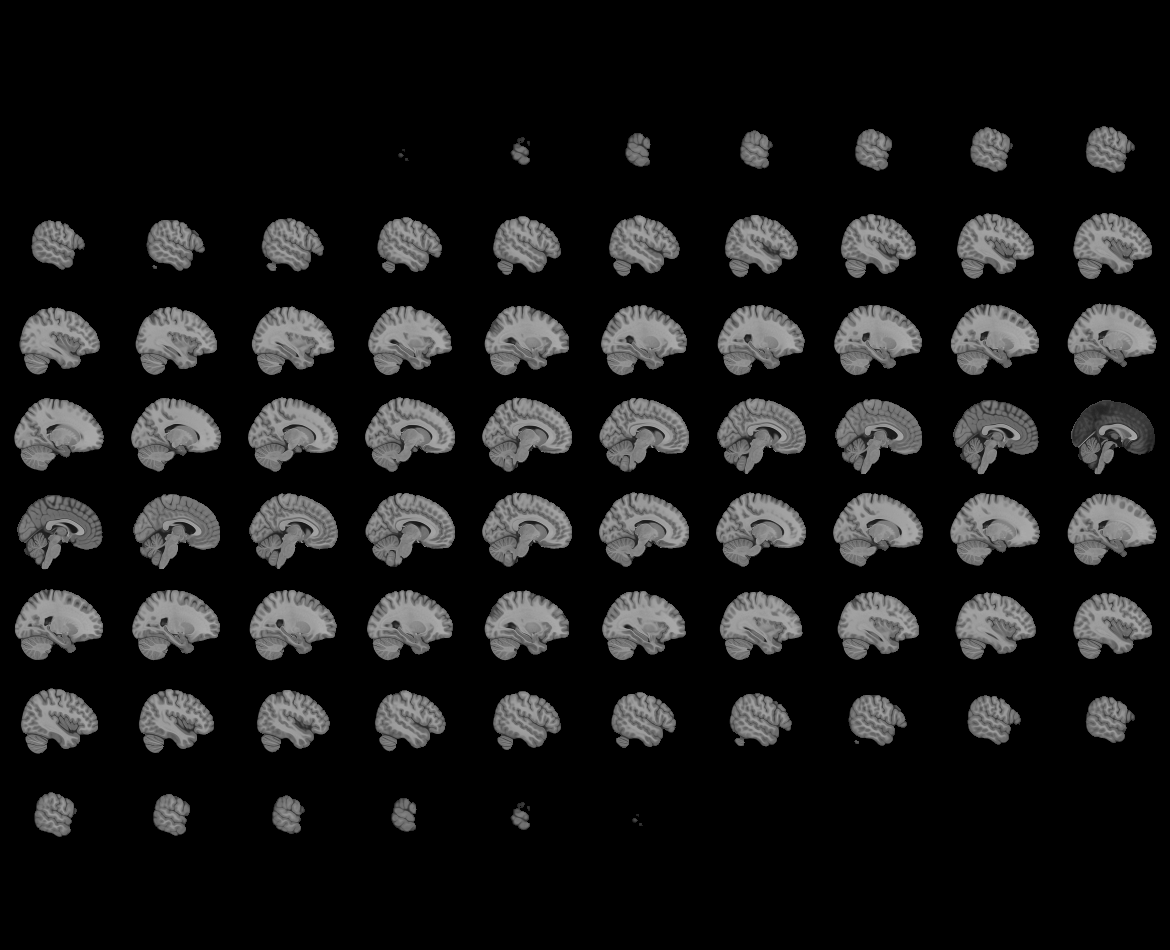
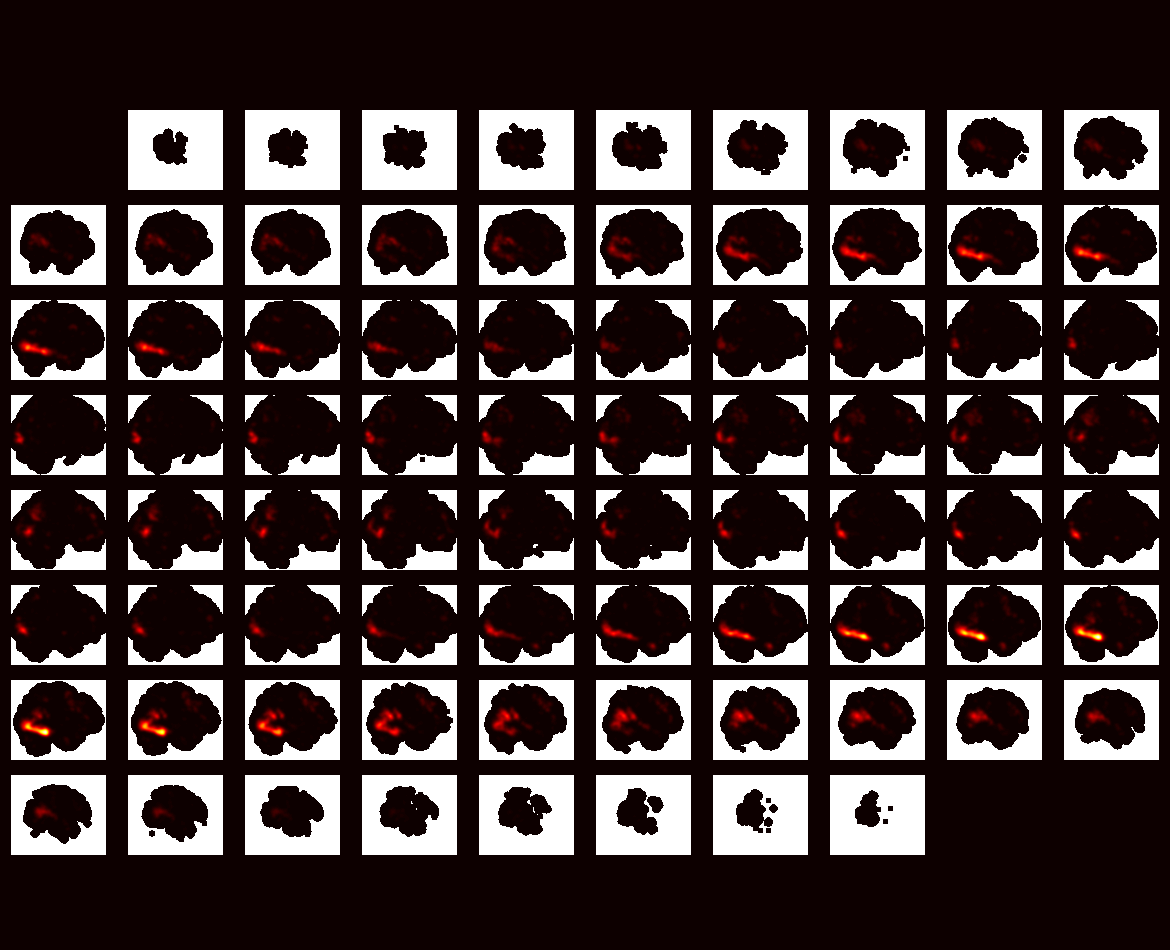

In [116]:
plotting.view_img(join(outdir,"masking","sm_sum_face_v_objects.nii"))

In [106]:
# Make smoothed maps to identify the peaks
def smooth_maps(input_nii_path,output_nii_path,fwhm): 
    # Load NIfTI file
    nii = nib.load(input_nii_path)
    vol = nii.get_fdata()
    # Smooth original volume
    sigma_voxels = fwhm / 2.3548 / 2
    smoothed_data = gaussian_filter(vol, sigma=sigma_voxels)
    smoothed_data_nii = nib.Nifti1Image(smoothed_data, affine=nii.affine, header=nii.header)
    nib.save(smoothed_data_nii, output_nii_path)

smooth_maps(join(outdir,'masking','sum_face_v_objects.nii'),join(outdir,'masking','sm_sum_face_v_objects.nii'),6)
smooth_maps(join(outdir,'masking','sum_scene_v_objects.nii'),join(outdir,'masking','sm_sum_scene_v_objects.nii'),6)
smooth_maps(join(outdir,'masking','sum_body_v_objects.nii'),join(outdir,'masking','sm_sum_body_v_objects.nii'),6)


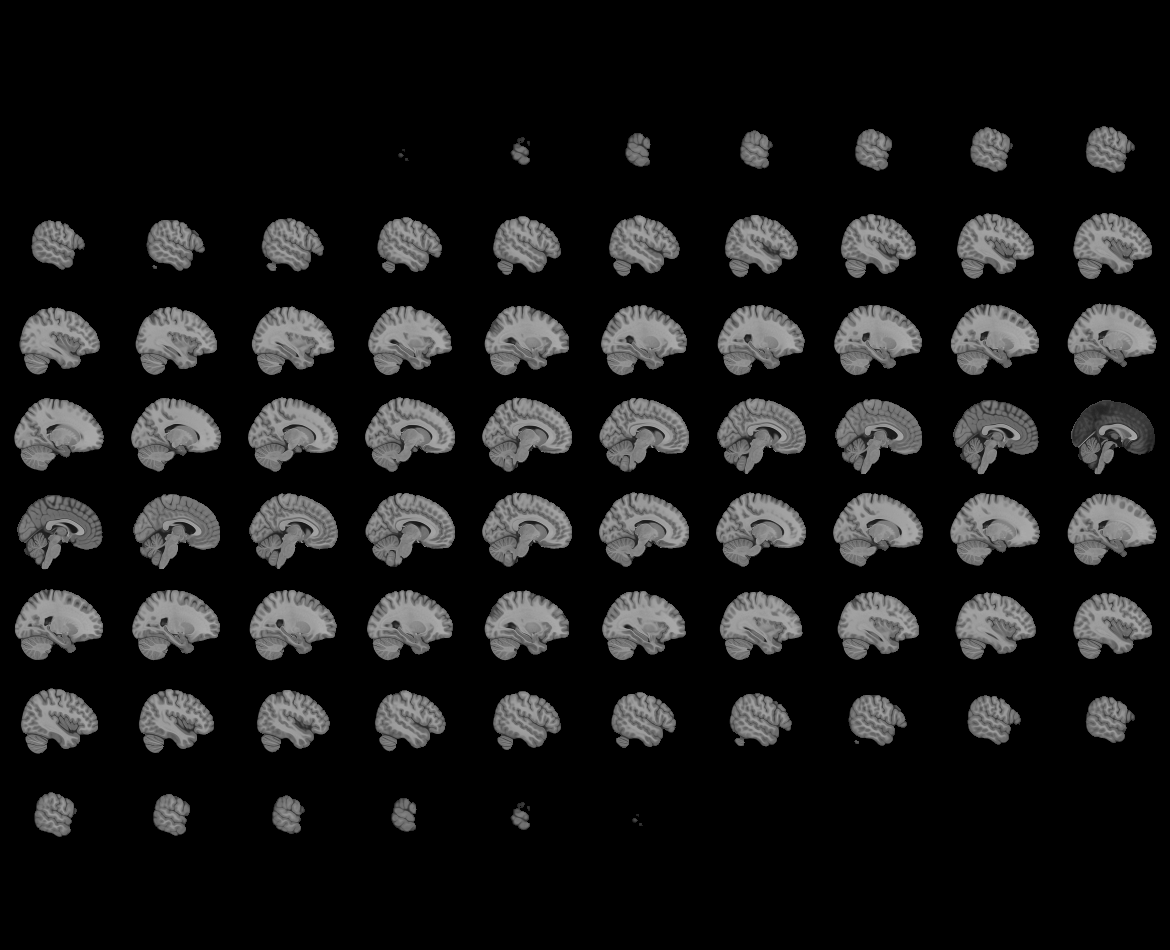
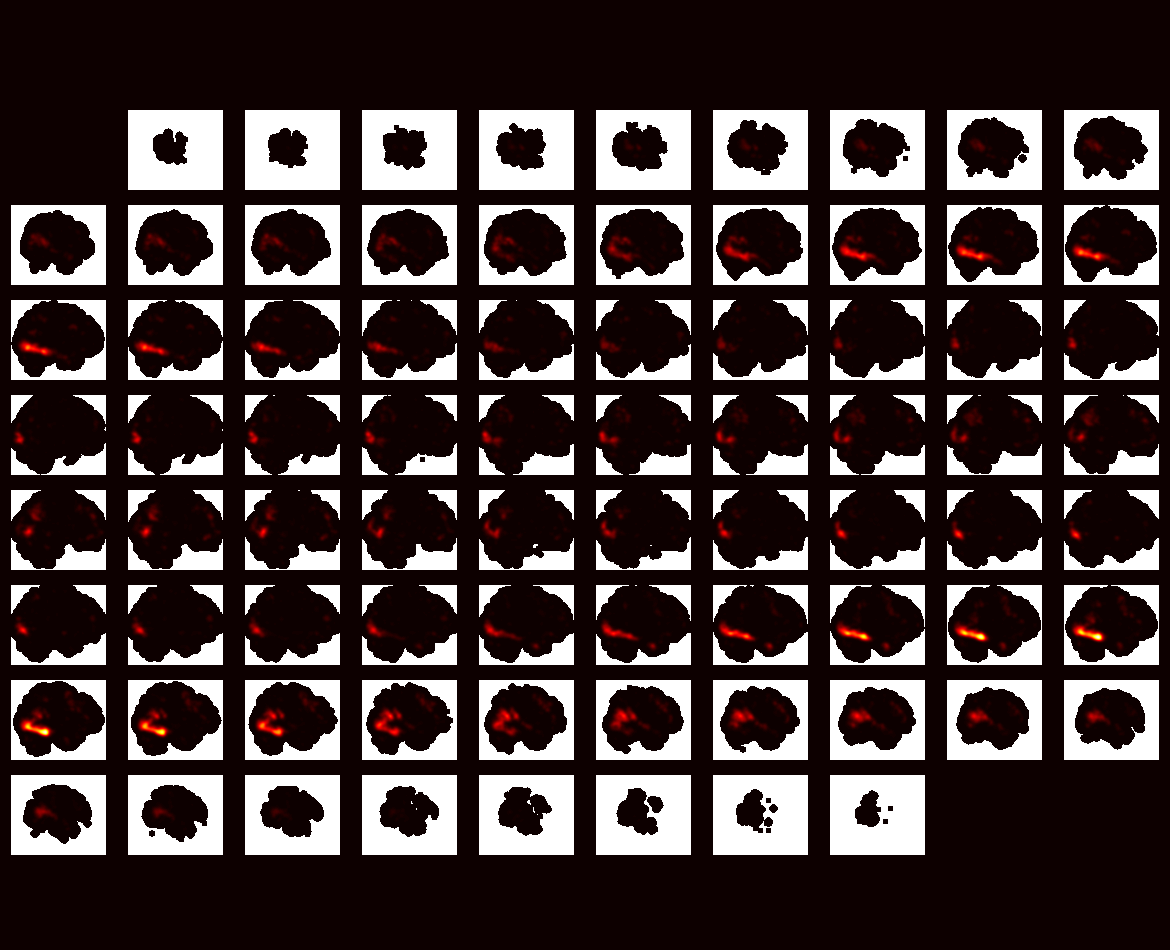

In [107]:
plotting.view_img(image.load_img(join(outdir,'masking','sm_sum_face_v_objects.nii')))

In [112]:
import numpy as np
import nibabel as nib
from skimage.segmentation import watershed

def segment_cluster_with_watershed(
    nii_file,           # Path to the input functional/stat map
    cluster_file,       # Path to labeled clusters NIfTI file
    mni_coords,         # Nx3 array of MNI coordinates (float)
    cluster_number,     # Integer label of the cluster to segment
    output_file,        # Path to save the output segmentation
    hemisphere,         # Left or right
    fwhm=6              # Optional: FWHM for smoothing (default 6 mm)
):
    # Load NIfTI images
    nii = nib.load(nii_file)
    vol = nii.get_fdata()
    vol[vol < 2] = 0  # Threshold

    cluster_nii = nib.load(cluster_file)
    cluster_data = cluster_nii.get_fdata()
    shape_x = cluster_data.shape[0]

    if hemisphere == "left":
        mask = np.zeros_like(cluster_data)
        mask[:round(shape_x/2), :, :] = 1
        cluster_data = mask * cluster_data
    if hemisphere == "right":
        mask = np.zeros_like(cluster_data)
        mask[round(shape_x/2):, :, :] = 1
        cluster_data = mask * cluster_data

    # Convert MNI to voxel indices
    affine_inv = np.linalg.inv(nii.affine)
    mni_homogeneous = np.hstack([mni_coords, np.ones((mni_coords.shape[0], 1))])
    voxel_coords_homogeneous = mni_homogeneous @ affine_inv.T
    voxel_coords_int = np.floor(voxel_coords_homogeneous[:, :3]).astype(int)

    # Smooth original volume
    sigma_voxels = fwhm / 2.3548 / 2
    smoothed_data = gaussian_filter(vol, sigma=sigma_voxels)

    # Mask for the selected cluster
    cluster_mask = cluster_data == cluster_number
    cluster_values = smoothed_data * cluster_mask

    # Create seed marker array
    markers = np.zeros(cluster_values.shape, dtype=np.int32)
    for i, (x, y, z) in enumerate(voxel_coords_int, start=1):
        if (0 <= x < markers.shape[0]) and (0 <= y < markers.shape[1]) and (0 <= z < markers.shape[2]):
            markers[x, y, z] = i
        else:
            print(f"ERROR: Seed {i} at {x, y, z} is out of bounds!")

    # Apply watershed to segment the cluster
    labels = watershed(-cluster_values, markers=markers, mask=cluster_mask)

    # Save to output NIfTI
    segmented_nii = nib.Nifti1Image(labels.astype(np.int16), affine=nii.affine, header=nii.header)
    nib.save(segmented_nii, output_file)

    print(f"Segment written to: {output_file}")

# RIGHT FACE REGIONS
# Specify coordinates of peaks
mni_coords = np.array([
    [44, -46, -16],
    [44, -78, -4],
    [52, -62, 24]
])
segment_cluster_with_watershed(
    nii_file=join(outdir,'masking','sum_face_v_objects.nii'),
    cluster_file=join(outdir,'masking','sum_face_clusters.nii'),
    mni_coords=mni_coords,
    cluster_number=1,
    output_file=join(outdir,'masking','right_face_segments.nii'),
    fwhm=6,
    hemisphere="right"
)

# LEFT FACE REGIONS
# Specify coordinates of peaks
mni_coords = np.array([
    [-38, -46, -14],
    [-38, -78, -4]
    #[-44, -68, 18]
])
segment_cluster_with_watershed(
    nii_file=join(outdir,'masking','sum_face_v_objects.nii'),
    cluster_file=join(outdir,'masking','sum_face_clusters.nii'),
    mni_coords=mni_coords,
    cluster_number=2,
    output_file=join(outdir,'masking','left_face_segments.nii'),
    fwhm=6,
    hemisphere="left"
)

# SCENE REGIONS
# Specify coordinates of peaks
mni_coords = np.array([
    [26, -42, -8], #right
    [16, -92, 4], #right
    [22, -50, 10] #right
])
segment_cluster_with_watershed(
    nii_file=join(outdir,'masking','sum_scene_v_objects.nii'),
    cluster_file=join(outdir,'masking','sum_scene_clusters.nii'),
    mni_coords=mni_coords,
    cluster_number=1,
    output_file=join(outdir,'masking','right_scene_segments.nii'),
    fwhm=6, 
    hemisphere="right"
)

# LEFT SCENE REGIONS
# Specify coordinates of peaks
mni_coords = np.array([
    [-28, -42, -4],
    [-8, -92, 2],
    [-18, -56, 12]
])
segment_cluster_with_watershed(
    nii_file=join(outdir,'masking','sum_scene_v_objects.nii'),
    cluster_file=join(outdir,'masking','sum_scene_clusters.nii'),
    mni_coords=mni_coords,
    cluster_number=1,
    output_file=join(outdir,'masking','left_scene_segments.nii'),
    fwhm=6,
    hemisphere="left"
)

# RIGHT BODY REGIONS
# Specify coordinates of peaks
mni_coords = np.array([
    [52, -66, 12],
    [46, -42, -14],
])
segment_cluster_with_watershed(
    nii_file=join(outdir,'masking','sum_body_v_objects.nii'),
    cluster_file=join(outdir,'masking','sum_body_clusters.nii'),
    mni_coords=mni_coords,
    cluster_number=1,
    output_file=join(outdir,'masking','right_body_segments.nii'),
    fwhm=6, 
    hemisphere="right"
)

# LEFT BODY REGIONS
# Specify coordinates of peaks
mni_coords = np.array([
    [-46, -74, 12],
    [-38, -44, -14]
])
segment_cluster_with_watershed(
    nii_file=join(outdir,'masking','sum_body_v_objects.nii'),
    cluster_file=join(outdir,'masking','sum_body_clusters.nii'),
    mni_coords=mni_coords,
    cluster_number=2,
    output_file=join(outdir,'masking','left_body_segments.nii'),
    fwhm=6, 
    hemisphere="right"
)

Segment written to: /Users/danieljanini/Documents/project_miniblock/miniblock/Outputs/masking/right_face_segments.nii
Segment written to: /Users/danieljanini/Documents/project_miniblock/miniblock/Outputs/masking/left_face_segments.nii
Segment written to: /Users/danieljanini/Documents/project_miniblock/miniblock/Outputs/masking/right_scene_segments.nii
Segment written to: /Users/danieljanini/Documents/project_miniblock/miniblock/Outputs/masking/left_scene_segments.nii
Segment written to: /Users/danieljanini/Documents/project_miniblock/miniblock/Outputs/masking/right_body_segments.nii
Segment written to: /Users/danieljanini/Documents/project_miniblock/miniblock/Outputs/masking/left_body_segments.nii



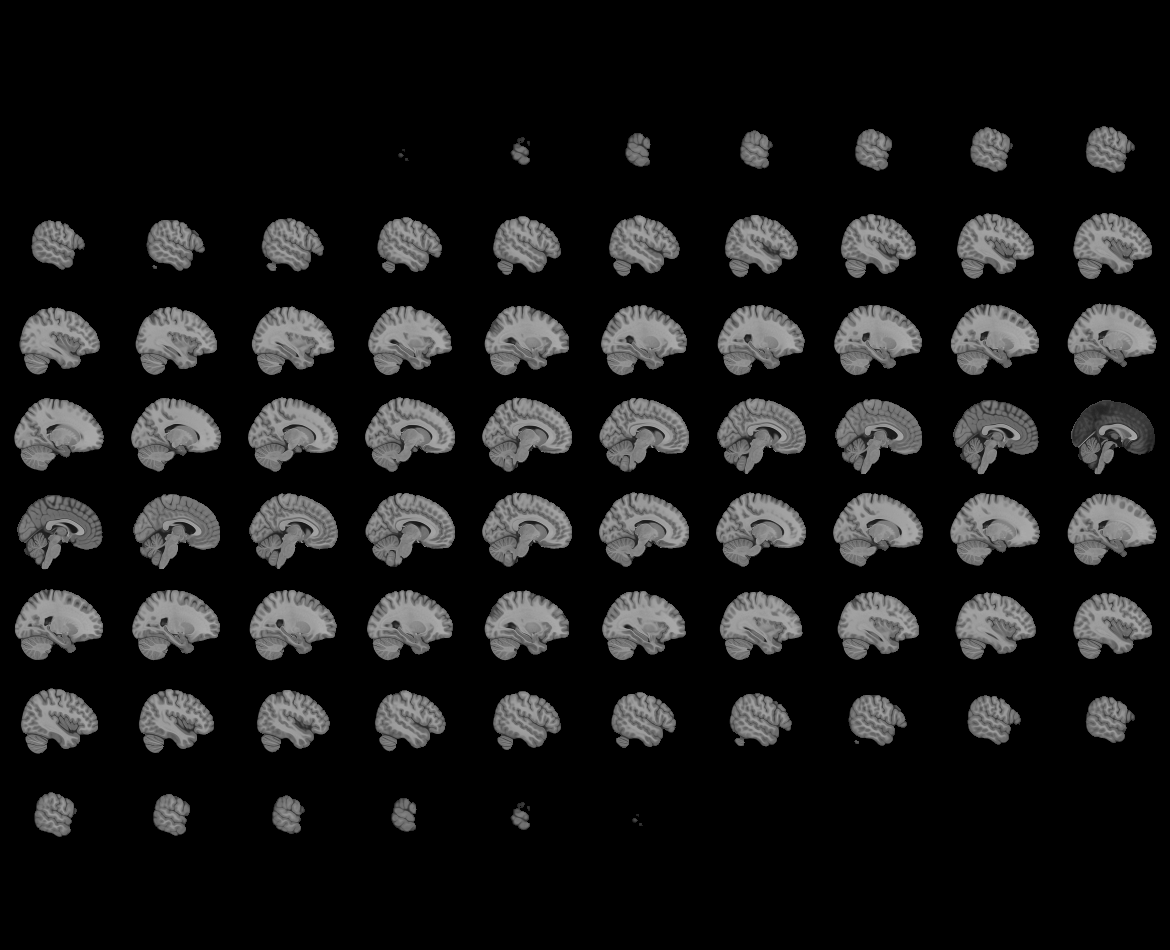
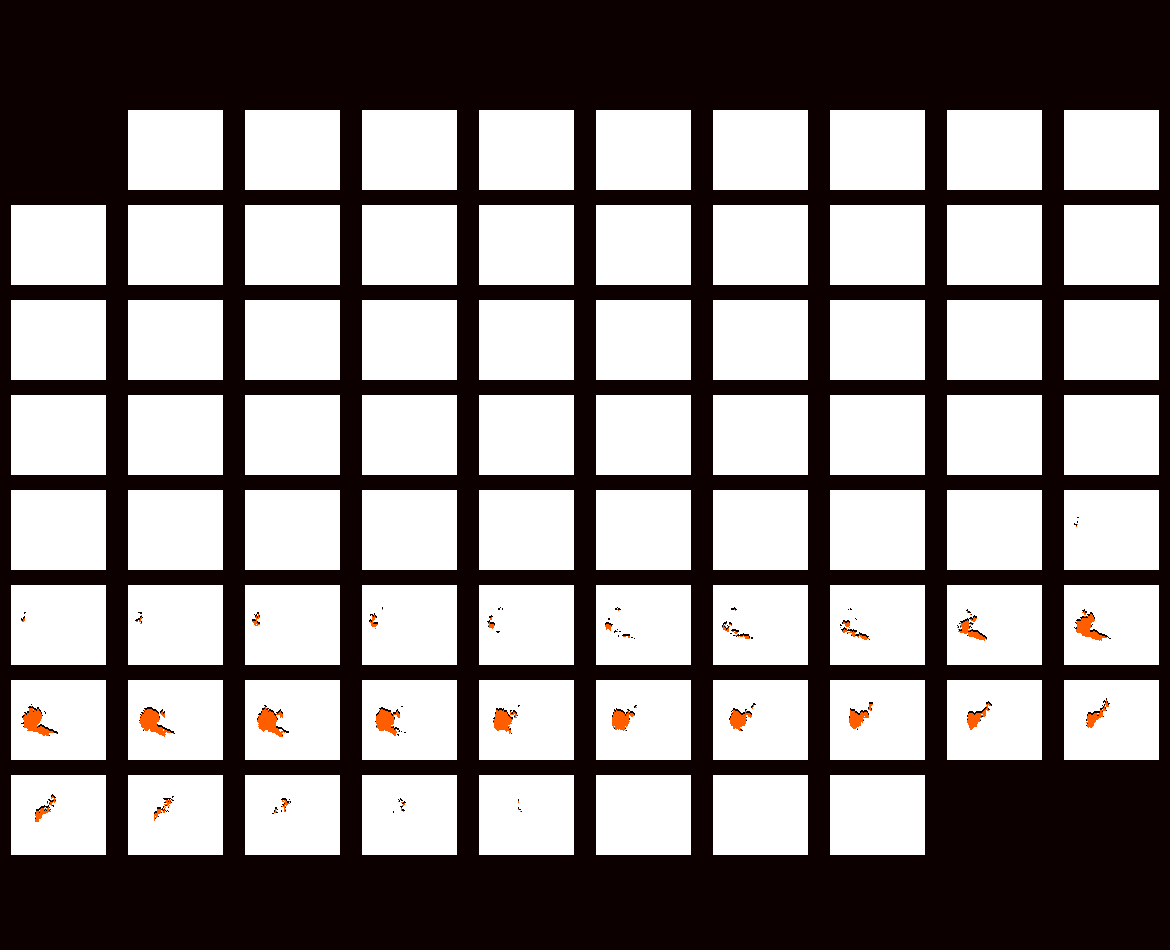

In [114]:
plotting.view_img(join(outdir,"masking","right_body_segments.nii"))

In [124]:
output_dir = join(outdir, "masking/parcels")
#os.mkdir(output_dir)

In [177]:
# Specify which clusters/segments are which ROIs
import nibabel as nib
import numpy as np
from pathlib import Path

def getSeparateParcels(regionDict,niiFile):
    # === Load cluster data
    cluster_nii = nib.load(niiFile)
    cluster_data = cluster_nii.get_fdata()

    # === Output directory
    #output_dir = join(outdir, "parcels")
    #os.mkdir(output_dir)

    # === Loop through each region and save its mask
    for region_name, label_id in regionDict.items():
        mask = (cluster_data == label_id).astype(np.int16)
        region_nii = nib.Nifti1Image(mask, affine=cluster_nii.affine, header=cluster_nii.header)
        nib.save(region_nii, join(output_dir, f'{region_name}.nii.gz'))

# SCENE REGIONS
scene_regions = {
    'rPPA': 1,
    'rOPA': 2,
    'rMPA': 3,
}
sceneClusterFile = join(outdir,'masking','right_scene_segments.nii')
getSeparateParcels(regionDict=scene_regions,niiFile=sceneClusterFile)

# SCENE REGIONS
scene_regions = {
    'lPPA': 1,
    'lOPA': 2,
    'lMPA': 3
}
sceneClusterFile = join(outdir,'masking','left_scene_segments.nii')
getSeparateParcels(regionDict=scene_regions,niiFile=sceneClusterFile)

# FACE REGIONS
face_regions = {
    'rFFA': 1,
    'rOFA': 2,
    'rSTS': 3
}
faceSegmentFile = join(outdir,'masking','right_face_segments.nii')
getSeparateParcels(regionDict=face_regions,niiFile=faceSegmentFile)

# FACE REGIONS
face_regions = {
    'lFFA': 1,
    'lOFA': 2,
    'lSTS': 3
}
faceSegmentFile = join(outdir,'masking','left_face_segments.nii')
getSeparateParcels(regionDict=face_regions,niiFile=faceSegmentFile)

# BODY REGIONS
body_regions = {
    'rEBA': 1,
    'rFBA': 2
}
faceSegmentFile = join(outdir,'masking','right_body_segments.nii')
getSeparateParcels(regionDict=body_regions,niiFile=faceSegmentFile)

# BODY REGIONS
body_regions = {
    'lEBA': 1,
    'lFBA': 2
}
faceSegmentFile = join(outdir,'masking','left_body_segments.nii')
getSeparateParcels(regionDict=body_regions,niiFile=faceSegmentFile)

In [163]:
from nilearn import plotting


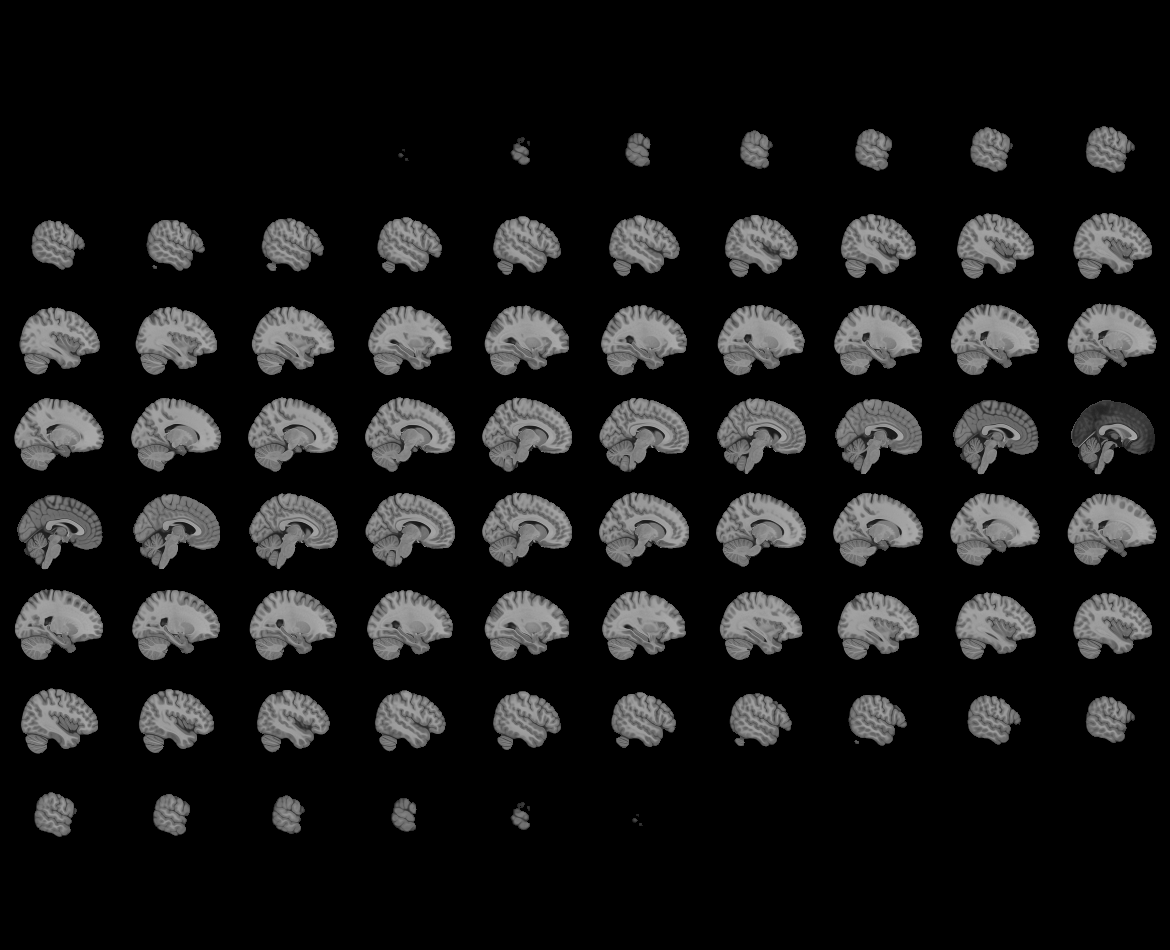
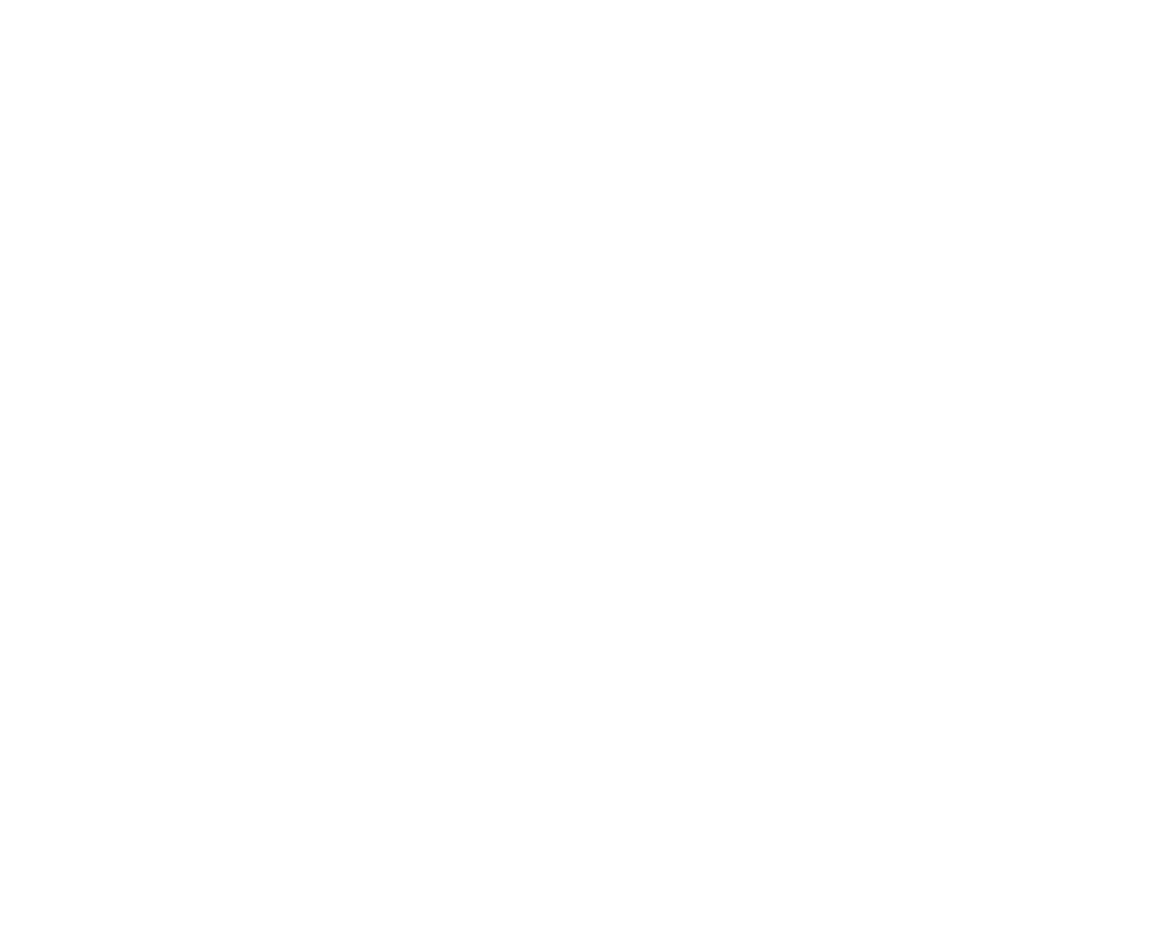

In [182]:
plotting.view_img(join(outdir,"masking/parcels","rFBA.nii.gz"))